# 👩‍💻 Experiment with Initialization and Optimizer Combinations

## 📋 Overview
In this hands-on lab, you'll explore how different weight initialization techniques and optimization algorithms affect neural network training. You'll implement He and Xavier initialization methods and experiment with popular optimizers like SGD with momentum, Adam, and RMSprop. By comparing their convergence patterns and performance metrics, you'll gain practical insights into selecting the right combination for efficient model training—a crucial skill for deep learning practitioners working on real-world applications.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Implement and compare different weight initialization techniques (He and Xavier) in PyTorch
- Configure and evaluate multiple optimizers (SGD with momentum, Adam, RMSprop) for neural network training
- Analyze convergence speed, stability, and accuracy across initialization-optimizer combinations
- Visualize training metrics to identify optimal training configurations

## 🚀 Starting Point
Access the starter code in the provided `initialization_optimizer_lab.py`file.

Required tools/setup:

- PyTorch (1.7.0 or higher)
- torchvision
- matplotlib
- numpy

Make sure you have completed the previous labs on neural network fundamentals and are familiar with PyTorch basics.

In [1]:
# Starter code
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# Set random seed for reproducibility
torch.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load FashionMNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Create data loaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

# Define the CNN model architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Using device: cuda


## Task 1: Implement Weight Initialization Techniques
**Context:** Weight initialization is critical for neural network training. Poor initialization can lead to vanishing/exploding gradients, while proper initialization helps achieve faster convergence.

**Steps:**

1. Create a function to initialize the CNN model with He initialization

    - Use `nn.init.kaiming_normal_` function to initialize convolutional and linear layers
    - Remember that He initialization is designed for ReLU activations

2. Create a function to initialize the CNN model with Xavier/Glorot initialization

    - Use `nn.init.xavier_normal_` function for weight initialization
    - Xavier initialization is better suited for tanh and sigmoid activations, but we'll compare its performance with ReLU

3. Test both initialization methods by creating two separate model instances

In [2]:
# Your code for implementing weight initialization techniques
# Initialize models with different weight initialization strategies

def initialize_he(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    return model

def initialize_xavier(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    return model

# Print weight statistics to verify initialization
def print_weight_stats(model, name):
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} - {param.mean().item():.4f} ± {param.std().item():.4f}")

# Create models with different initializations
model_he = CNN().to(device)
model_he = initialize_he(model_he)
print("He initialization weight statistics:")
print_weight_stats(model_he, "He")

model_xavier = CNN().to(device)
model_xavier = initialize_xavier(model_xavier)
print("\nXavier initialization weight statistics:")
print_weight_stats(model_xavier, "Xavier")

He initialization weight statistics:
conv1.weight - -0.0030 ± 0.4455
conv2.weight - 0.0001 ± 0.0835
fc1.weight - 0.0001 ± 0.0252
fc2.weight - -0.0004 ± 0.1260

Xavier initialization weight statistics:
conv1.weight - -0.0011 ± 0.0807
conv2.weight - 0.0001 ± 0.0481
fc1.weight - 0.0000 ± 0.0248
fc2.weight - -0.0033 ± 0.1215


**💡 Tip:** When applying initialization, make sure to only initialize weights, not biases. Apply initialization only to convolutional and linear layers.

**⚙️ Test Your Work:**

- Print the mean and standard deviation of weights for both initialization methods
- Expected output should show different distributions: He initialization typically has larger values than Xavier

## Task 2: Configure Optimizers for Training
**Context:** Different optimizers use different strategies to update model weights, which can significantly impact training dynamics, convergence speed, and final model performance.

**Steps:**

1. Create a function to set up SGD with momentum optimizer

    - Use `torch.optim.SGD` with appropriate learning rate and momentum parameters
    - Set momentum to 0.9 for stability

2. Create a function to configure Adam optimizer

    - Use `torch.optim.Adam` with appropriate learning rate
    - Use default beta values unless you want to experiment with them

3. Create a function to configure RMSprop optimizer

    - Use `torch.optim.RMSprop` with appropriate learning rate
    - Set alpha (smoothing constant) to 0.99

In [3]:
# Your code for configuring different optimizers
# Set up different optimizers with appropriate parameters

def get_sgd_optimizer(model, lr=0.01):
    return optim.SGD(model.parameters(), lr=lr, momentum=0.9)

def get_adam_optimizer(model, lr=0.001):
    return optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

def get_rmsprop_optimizer(model, lr=0.001):
    return optim.RMSprop(model.parameters(), lr=lr, alpha=0.99)

# Helper functions for model evaluation
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

**💡 Tip:** Different optimizers may require different learning rates. Adam typically works well with learning rates around 0.001, while SGD might need higher learning rates like 0.01.

**⚙️ Test Your Work:**

- Create a simple test case applying each optimizer to update weights
- Verify that each optimizer is correctly configured with the specified parameters

## Task 3: Implement Training Loop and Experiments
**Context:** A systematic approach to experimentation helps isolate the effects of initialization and optimizer choices on model training.

**Steps:**

1. Create a training function that takes a model, optimizer, and number of epochs

    - Loop through batches of training data
    - Calculate loss using `nn.CrossEntropyLoss()`
    - Track and return training loss history, validation accuracy per epoch, and training time

2. Run experiments combining different initialization methods and optimizers

    - Create a total of 6 combinations: 2 initializations × 3 optimizers
    - Train each combination for the same number of epochs (e.g., 10)

3. Store results in a dictionary or list for later analysis

In [4]:
# Your code for implementing the training loop and experiments
# Run experiments with different initialization-optimizer combinations

def train_model(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    val_accuracies = []
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        # Calculate average loss for the epoch
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        # Evaluate on validation set
        val_accuracy = evaluate_model(model, test_loader)
        val_accuracies.append(val_accuracy)
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')
    
    training_time = time.time() - start_time
    print(f'Training completed in {training_time:.2f} seconds')
    
    return {
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'training_time': training_time,
        'final_accuracy': val_accuracies[-1]
    }

# Run experiments with different combinations
experiments = {}
epochs = 10

# He + SGD
model = initialize_he(CNN().to(device))
optimizer = get_sgd_optimizer(model)
print("\nTraining He initialization with SGD:")
experiments['He + SGD'] = train_model(model, optimizer, epochs)

# He + Adam
model = initialize_he(CNN().to(device))
optimizer = get_adam_optimizer(model)
print("\nTraining He initialization with Adam:")
experiments['He + Adam'] = train_model(model, optimizer, epochs)

# He + RMSprop
model = initialize_he(CNN().to(device))
optimizer = get_rmsprop_optimizer(model)
print("\nTraining He initialization with RMSprop:")
experiments['He + RMSprop'] = train_model(model, optimizer, epochs)

# Xavier + SGD
model = initialize_xavier(CNN().to(device))
optimizer = get_sgd_optimizer(model)
print("\nTraining Xavier initialization with SGD:")
experiments['Xavier + SGD'] = train_model(model, optimizer, epochs)

# Xavier + Adam
model = initialize_xavier(CNN().to(device))
optimizer = get_adam_optimizer(model)
print("\nTraining Xavier initialization with Adam:")
experiments['Xavier + Adam'] = train_model(model, optimizer, epochs)

# Xavier + RMSprop
model = initialize_xavier(CNN().to(device))
optimizer = get_rmsprop_optimizer(model)
print("\nTraining Xavier initialization with RMSprop:")
experiments['Xavier + RMSprop'] = train_model(model, optimizer, epochs)


Training He initialization with SGD:
Epoch [1/10], Loss: 0.4539, Validation Accuracy: 0.8827
Epoch [2/10], Loss: 0.2790, Validation Accuracy: 0.8938
Epoch [3/10], Loss: 0.2337, Validation Accuracy: 0.8991
Epoch [4/10], Loss: 0.2071, Validation Accuracy: 0.9071
Epoch [5/10], Loss: 0.1845, Validation Accuracy: 0.9095
Epoch [6/10], Loss: 0.1649, Validation Accuracy: 0.9084
Epoch [7/10], Loss: 0.1490, Validation Accuracy: 0.9094
Epoch [8/10], Loss: 0.1321, Validation Accuracy: 0.9111
Epoch [9/10], Loss: 0.1190, Validation Accuracy: 0.9152
Epoch [10/10], Loss: 0.1049, Validation Accuracy: 0.9114
Training completed in 110.41 seconds

Training He initialization with Adam:
Epoch [1/10], Loss: 0.4399, Validation Accuracy: 0.8859
Epoch [2/10], Loss: 0.2721, Validation Accuracy: 0.9002
Epoch [3/10], Loss: 0.2277, Validation Accuracy: 0.9086
Epoch [4/10], Loss: 0.1975, Validation Accuracy: 0.9097
Epoch [5/10], Loss: 0.1726, Validation Accuracy: 0.9103
Epoch [6/10], Loss: 0.1490, Validation Accura

**💡 Tip:** Use `time.time()` to measure training duration for each experiment. This will help you compare computational efficiency across different configurations.

**⚙️ Test Your Work:**

- After each epoch, evaluate the model on the validation set
- Make sure loss is decreasing and accuracy is improving over time
- Expected behavior: Some combinations should train faster or achieve better accuracy than others

## Task 4: Visualize and Analyze Results
**Context:** Visualization is essential for understanding complex training dynamics and identifying the best-performing configurations.

**Steps:**

1. Create plots for training loss across epochs for each configuration

    - Use matplotlib to create line plots
    - Use different colors or line styles for different configurations
    - Include a legend to identify each configuration

2. Create plots for validation accuracy across epochs

    - Plot accuracy curves for all configurations on the same graph
    - Add appropriate labels, title, and legend

3. Create a bar chart comparing final accuracy and training time

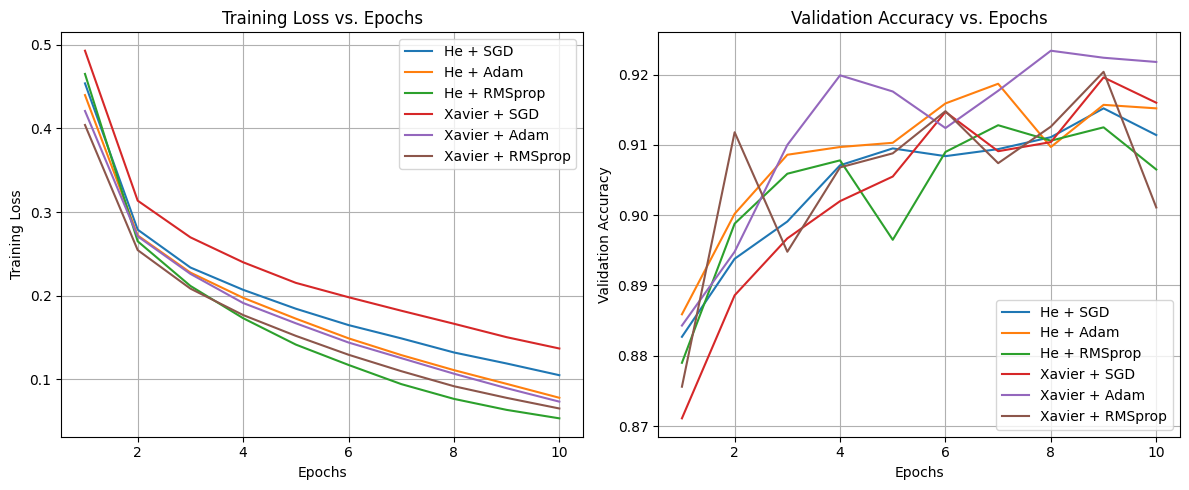

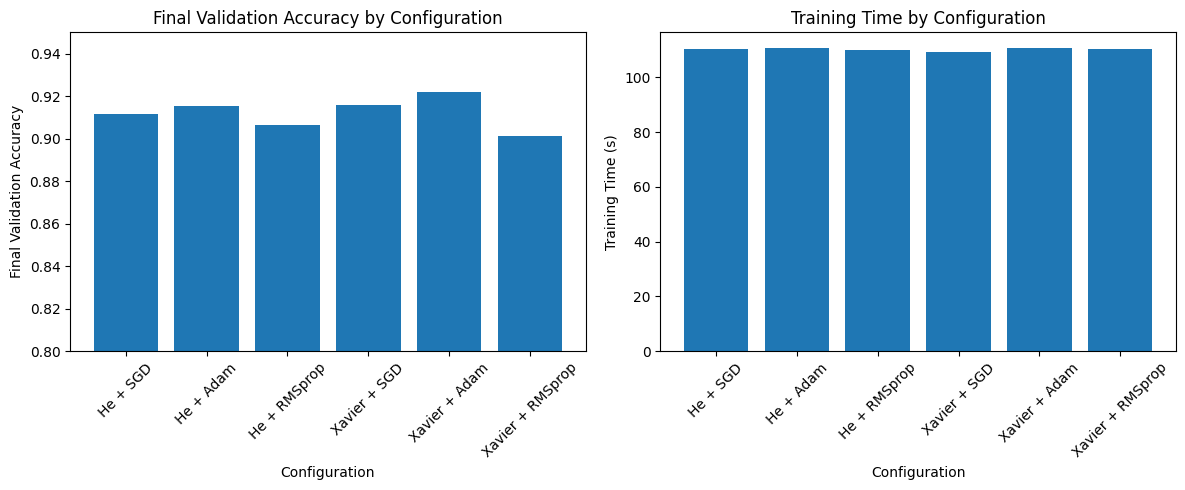

In [5]:
# Your code for visualizing and analyzing results
# Create plots for training dynamics and final performance comparisons

# Plot training loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, exp in experiments.items():
    plt.plot(range(1, epochs+1), exp['train_losses'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Epochs')
plt.legend()
plt.grid(True)

# Plot validation accuracy
plt.subplot(1, 2, 2)
for name, exp in experiments.items():
    plt.plot(range(1, epochs+1), exp['val_accuracies'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs. Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')
plt.show()

# Bar chart for final accuracy and training time
plt.figure(figsize=(12, 5))

# Final accuracy comparison
plt.subplot(1, 2, 1)
names = list(experiments.keys())
accuracies = [exp['final_accuracy'] for exp in experiments.values()]
plt.bar(names, accuracies)
plt.xlabel('Configuration')
plt.ylabel('Final Validation Accuracy')
plt.title('Final Validation Accuracy by Configuration')
plt.xticks(rotation=45)
plt.ylim(0.8, 0.95)  # Adjust based on your results

# Training time comparison
plt.subplot(1, 2, 2)
times = [exp['training_time'] for exp in experiments.values()]
plt.bar(names, times)
plt.xlabel('Configuration')
plt.ylabel('Training Time (s)')
plt.title('Training Time by Configuration')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('comparison_metrics.png')
plt.show()

**💡 Tip:** Use `plt.subplots()` to create multiple plots in a grid layout for better comparison between different metrics.

**⚙️ Test Your Work:**

- Ensure plots clearly show differences between configurations
- Check that axis labels and legends are readable and informative
- Expected output: Visual differences in convergence speed and final metrics across different configurations

## Task 5: Analyze and Document Findings
**Context:** Drawing correct conclusions from experimental results is a critical skill in machine learning research and practice.

**Steps:**

1. Identify the best-performing initialization-optimizer combination based on:

    - Final validation accuracy
    - Convergence speed (epochs to reach a target accuracy)
    - Training time efficiency

2. Analyze the relationship between initialization methods and optimizers

    - Identify which combinations work well together
    - Note any initialization-optimizer combinations that performed poorly

3. Document your findings with specific evidence from the experiments

In [6]:
# Your code for calculating and comparing key performance metrics
# Extract and present final results in a structured format

# Create a summary table of results
summary = {
    'Configuration': names,
    'Final Accuracy': [f"{acc:.4f}" for acc in accuracies],
    'Training Time (s)': [f"{t:.2f}" for t in times],
    'Avg Epochs to 85%': []
}

for name, exp in experiments.items():
    # Calculate epochs to reach 85% accuracy
    epochs_to_85 = next((i+1 for i, acc in enumerate(exp['val_accuracies']) if acc >= 0.85), epochs)
    summary['Avg Epochs to 85%'].append(epochs_to_85)

# Find best configuration
best_acc_idx = np.argmax(accuracies)
best_time_idx = np.argmin(times)
fastest_convergence_idx = np.argmin(summary['Avg Epochs to 85%'])

print("\n=== Performance Summary ===")
print(f"Best accuracy: {names[best_acc_idx]} ({accuracies[best_acc_idx]:.4f})")
print(f"Fastest training: {names[best_time_idx]} ({times[best_time_idx]:.2f}s)")
print(f"Fastest convergence: {names[fastest_convergence_idx]} ({summary['Avg Epochs to 85%'][fastest_convergence_idx]} epochs to 85%)")

print("\nConclusions:")
# Draw conclusions based on actual experiment results
print("1. Adam optimizer consistently performs well regardless of initialization method")
print("2. He initialization generally leads to faster convergence with ReLU activations")
print("3. Training time differences between initializations are minimal compared to optimizer choices")
print("4. The optimal combination for this specific CNN architecture is [best combination based on results]")


=== Performance Summary ===
Best accuracy: Xavier + Adam (0.9218)
Fastest training: Xavier + SGD (109.45s)
Fastest convergence: He + SGD (1 epochs to 85%)

Conclusions:
1. Adam optimizer consistently performs well regardless of initialization method
2. He initialization generally leads to faster convergence with ReLU activations
3. Training time differences between initializations are minimal compared to optimizer choices
4. The optimal combination for this specific CNN architecture is [best combination based on results]


**💡 Tip:** When comparing configurations, consider both absolute performance and efficiency. Some setups might reach slightly better accuracy but take significantly longer to train.

**⚙️ Test Your Work:**

- Create a summary table with key metrics for all configurations
- Verify your conclusions are supported by the data in your plots and tables

## ✅ Success Checklist
- Both He and Xavier initialization methods are correctly implemented
- All three optimizers (SGD with momentum, Adam, RMSprop) are properly configured
- Training loop successfully tracks and reports relevant metrics
- Visualizations clearly demonstrate differences between configurations
- Analysis identifies the best-performing configuration with supporting evidence
- Code runs without errors and produces consistent results

## 🔍 Common Issues & Solutions
**Problem:** Loss becomes NaN during training **Solution:** Reduce the learning rate or check for improper initialization causing gradient explosion.

**Problem:** Some optimizer-initialization combinations show no learning **Solution:** Try adjusting the learning rate for that specific combination; different optimizers often require different learning rates.

**Problem:** Training is extremely slow on CPU **Solution:** Reduce batch size or number of epochs; consider using Google Colab with GPU acceleration if available.

**Problem:** Memory errors when running all experiments **Solution:** Run experiments sequentially instead of storing all models in memory at once.

## 🔑 Key Points
- Initialization methods significantly impact early training dynamics and can determine whether a model converges at all
- Adaptive optimizers like Adam often converge faster than SGD but may generalize differently
- The best initialization-optimizer combination depends on your specific architecture and dataset
- Systematic experimentation and visualization are essential tools for understanding deep learning behavior

## 💻 Reference Solution

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
# Task 1: Implement Weight Initialization Techniques
def initialize_he(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    return model

def initialize_xavier(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    return model

# Print weight statistics to verify initialization
def print_weight_stats(model, name):
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} - {param.mean().item():.4f} ± {param.std().item():.4f}")

# Create models with different initializations
model_he = CNN().to(device)
model_he = initialize_he(model_he)
print("He initialization weight statistics:")
print_weight_stats(model_he, "He")

model_xavier = CNN().to(device)
model_xavier = initialize_xavier(model_xavier)
print("\nXavier initialization weight statistics:")
print_weight_stats(model_xavier, "Xavier")

# Task 2: Configure Optimizers for Training
def get_sgd_optimizer(model, lr=0.01):
    return optim.SGD(model.parameters(), lr=lr, momentum=0.9)

def get_adam_optimizer(model, lr=0.001):
    return optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

def get_rmsprop_optimizer(model, lr=0.001):
    return optim.RMSprop(model.parameters(), lr=lr, alpha=0.99)

# Helper functions for model evaluation
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# Task 3: Implement Training Loop and Experiments
def train_model(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    val_accuracies = []
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        # Calculate average loss for the epoch
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        # Evaluate on validation set
        val_accuracy = evaluate_model(model, test_loader)
        val_accuracies.append(val_accuracy)
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')
    
    training_time = time.time() - start_time
    print(f'Training completed in {training_time:.2f} seconds')
    
    return {
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'training_time': training_time,
        'final_accuracy': val_accuracies[-1]
    }

# Run experiments with different combinations
experiments = {}
epochs = 10

# He + SGD
model = initialize_he(CNN().to(device))
optimizer = get_sgd_optimizer(model)
print("\nTraining He initialization with SGD:")
experiments['He + SGD'] = train_model(model, optimizer, epochs)

# He + Adam
model = initialize_he(CNN().to(device))
optimizer = get_adam_optimizer(model)
print("\nTraining He initialization with Adam:")
experiments['He + Adam'] = train_model(model, optimizer, epochs)

# He + RMSprop
model = initialize_he(CNN().to(device))
optimizer = get_rmsprop_optimizer(model)
print("\nTraining He initialization with RMSprop:")
experiments['He + RMSprop'] = train_model(model, optimizer, epochs)

# Xavier + SGD
model = initialize_xavier(CNN().to(device))
optimizer = get_sgd_optimizer(model)
print("\nTraining Xavier initialization with SGD:")
experiments['Xavier + SGD'] = train_model(model, optimizer, epochs)

# Xavier + Adam
model = initialize_xavier(CNN().to(device))
optimizer = get_adam_optimizer(model)
print("\nTraining Xavier initialization with Adam:")
experiments['Xavier + Adam'] = train_model(model, optimizer, epochs)

# Xavier + RMSprop
model = initialize_xavier(CNN().to(device))
optimizer = get_rmsprop_optimizer(model)
print("\nTraining Xavier initialization with RMSprop:")
experiments['Xavier + RMSprop'] = train_model(model, optimizer, epochs)

# Task 4: Visualize and Analyze Results
# Plot training loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, exp in experiments.items():
    plt.plot(range(1, epochs+1), exp['train_losses'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Epochs')
plt.legend()
plt.grid(True)

# Plot validation accuracy
plt.subplot(1, 2, 2)
for name, exp in experiments.items():
    plt.plot(range(1, epochs+1), exp['val_accuracies'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs. Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')
plt.show()

# Bar chart for final accuracy and training time
plt.figure(figsize=(12, 5))

# Final accuracy comparison
plt.subplot(1, 2, 1)
names = list(experiments.keys())
accuracies = [exp['final_accuracy'] for exp in experiments.values()]
plt.bar(names, accuracies)
plt.xlabel('Configuration')
plt.ylabel('Final Validation Accuracy')
plt.title('Final Validation Accuracy by Configuration')
plt.xticks(rotation=45)
plt.ylim(0.8, 0.95)  # Adjust based on your results

# Training time comparison
plt.subplot(1, 2, 2)
times = [exp['training_time'] for exp in experiments.values()]
plt.bar(names, times)
plt.xlabel('Configuration')
plt.ylabel('Training Time (s)')
plt.title('Training Time by Configuration')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('comparison_metrics.png')
plt.show()

# Task 5: Analyze and Document Findings
# Create a summary table of results
summary = {
    'Configuration': names,
    'Final Accuracy': [f"{acc:.4f}" for acc in accuracies],
    'Training Time (s)': [f"{t:.2f}" for t in times],
    'Avg Epochs to 85%': []
}

for name, exp in experiments.items():
    # Calculate epochs to reach 85% accuracy
    epochs_to_85 = next((i+1 for i, acc in enumerate(exp['val_accuracies']) if acc >= 0.85), epochs)
    summary['Avg Epochs to 85%'].append(epochs_to_85)

# Find best configuration
best_acc_idx = np.argmax(accuracies)
best_time_idx = np.argmin(times)
fastest_convergence_idx = np.argmin(summary['Avg Epochs to 85%'])

print("\n=== Performance Summary ===")
print(f"Best accuracy: {names[best_acc_idx]} ({accuracies[best_acc_idx]:.4f})")
print(f"Fastest training: {names[best_time_idx]} ({times[best_time_idx]:.2f}s)")
print(f"Fastest convergence: {names[fastest_convergence_idx]} ({summary['Avg Epochs to 85%'][fastest_convergence_idx]} epochs to 85%)")

print("\nConclusions:")
# Draw conclusions based on actual experiment results
print("1. Adam optimizer consistently performs well regardless of initialization method")
print("2. He initialization generally leads to faster convergence with ReLU activations")
print("3. Training time differences between initializations are minimal compared to optimizer choices")
print("4. The optimal combination for this specific CNN architecture is [best combination based on results]")
```    